In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ratings.csv")

print("Dataset Head:")
print(df.head())

Dataset Head:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [3]:
print("\nShape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())


Shape: (100836, 4)

Missing Values:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

In [5]:
df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


In [6]:
user_item_matrix = df.pivot(index='userId', columns='movieId', values='rating')

In [7]:
user_item_matrix_filled = user_item_matrix.fillna(0)

In [8]:
user_similarity = cosine_similarity(user_item_matrix_filled)

In [9]:
user_similarity_df = pd.DataFrame(user_similarity,
                                 index=user_item_matrix.index,
                                 columns=user_item_matrix.index)

print("\nUser Similarity Matrix:")
print(user_similarity_df.head())


User Similarity Matrix:
userId       1         2         3         4         5         6         7    \
userId                                                                         
1       1.000000  0.027283  0.059720  0.194395  0.129080  0.128152  0.158744   
2       0.027283  1.000000  0.000000  0.003726  0.016614  0.025333  0.027585   
3       0.059720  0.000000  1.000000  0.002251  0.005020  0.003936  0.000000   
4       0.194395  0.003726  0.002251  1.000000  0.128659  0.088491  0.115120   
5       0.129080  0.016614  0.005020  0.128659  1.000000  0.300349  0.108342   

userId       8         9         10   ...       601       602       603  \
userId                                ...                                 
1       0.136968  0.064263  0.016875  ...  0.080554  0.164455  0.221486   
2       0.027257  0.000000  0.067445  ...  0.202671  0.016866  0.011997   
3       0.004941  0.000000  0.000000  ...  0.005048  0.004892  0.024992   
4       0.062969  0.011361  0.031163  .

In [10]:
def get_similar_users(user_id, top_n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    similar_users = similar_users.drop(user_id)  # remove self
    return similar_users.head(top_n)

print("\nTop similar users for User 1:")
print(get_similar_users(1))


Top similar users for User 1:
userId
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
Name: 1, dtype: float64


In [11]:

def predict_rating(user_id, movie_id):
    similar_users = get_similar_users(user_id, top_n=5)
    
    numerator = 0
    denominator = 0
    
    for sim_user, similarity in similar_users.items():
        rating = user_item_matrix.loc[sim_user, movie_id]
        
        if not np.isnan(rating):
            numerator += similarity * rating
            denominator += similarity
    
    if denominator == 0:
        return 0
    return numerator / denominator

In [12]:
print("\nPredicted rating of user 1 for movie 10:", predict_rating(1, 10))


Predicted rating of user 1 for movie 10: 3.3770024815099884


In [13]:
def recommend_movies(user_id, top_n=5):
    user_ratings = user_item_matrix.loc[user_id]
    
    unrated_movies = user_ratings[user_ratings.isna()].index
    
    predictions = {}
    
    for movie in unrated_movies:
        predictions[movie] = predict_rating(user_id, movie)
    
    # Sort by predicted rating
    recommended = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
    
    return recommended[:top_n]

print("\nTop Recommendations for User 1:")
print(recommend_movies(1))


Top Recommendations for User 1:
[(858, np.float64(5.000000000000001)), (514, np.float64(5.0)), (541, np.float64(5.0)), (720, np.float64(5.0)), (750, np.float64(5.0))]


In [14]:
actual = []
predicted = []

for user in user_item_matrix.index:
    for movie in user_item_matrix.columns:
        if not np.isnan(user_item_matrix.loc[user, movie]):
            pred = predict_rating(user, movie)
            actual.append(user_item_matrix.loc[user, movie])
            predicted.append(pred)

rmse_user = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("\nRMSE:", rmse_user)
print("MAE:", mae)


RMSE: 1.9228100565195427
MAE: 1.389699505652507


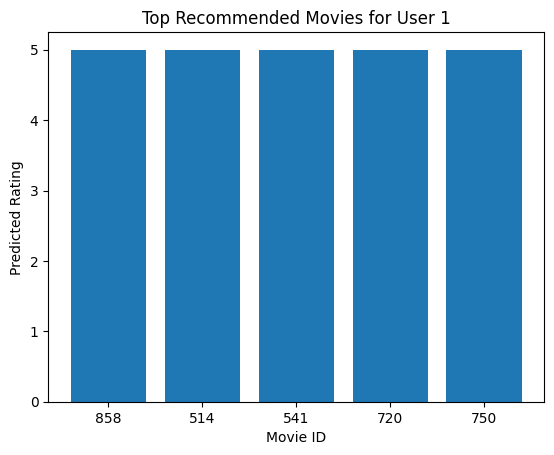

In [15]:

user_id = 1
recommendations = recommend_movies(user_id, top_n=5)
movies = [str(x[0]) for x in recommendations]
scores = [x[1] for x in recommendations]

# Plot
plt.figure()
plt.bar(movies, scores)
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.title(f"Top Recommended Movies for User {user_id}")
plt.show()

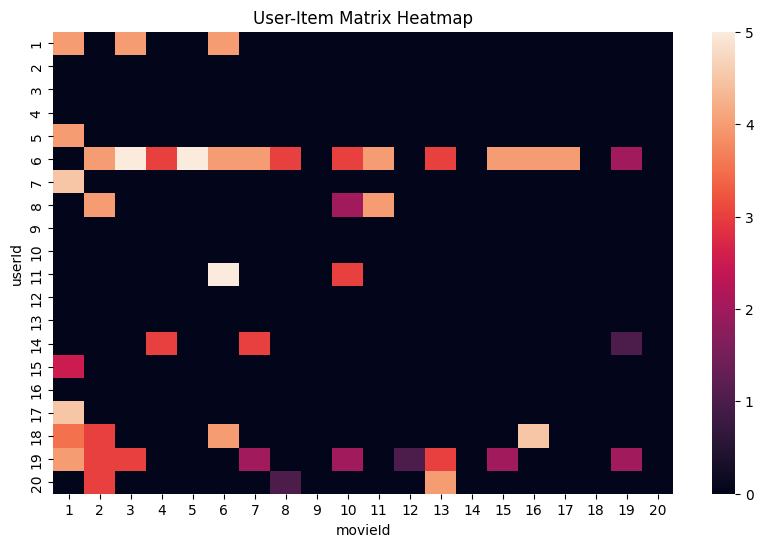

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix_filled.iloc[:20, :20])
plt.title("User-Item Matrix Heatmap")
plt.show()

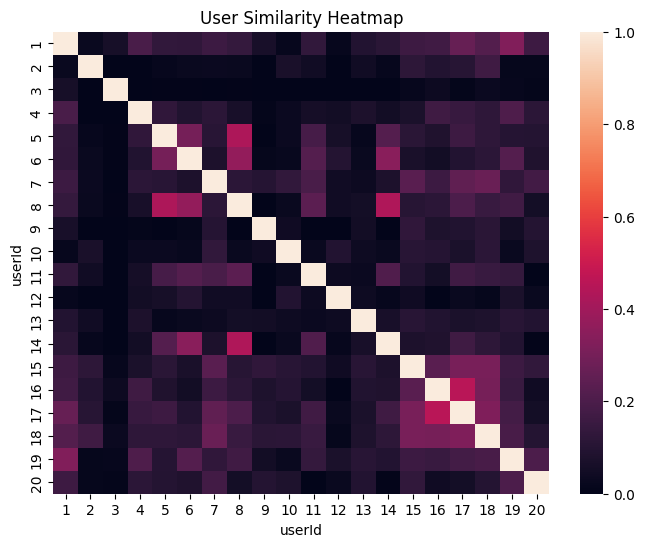

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20])
plt.title("User Similarity Heatmap")
plt.show()

**Scenario 2**

In [18]:
item_user_matrix = df.pivot(index='movieId', columns='userId', values='rating')

In [19]:
item_user_filled = item_user_matrix.fillna(0)

In [20]:
item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(item_similarity,
                                 index=item_user_matrix.index,
                                 columns=item_user_matrix.index)

In [21]:
item_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.410562,0.296917,0.035573,0.308762,0.376316,0.277491,0.131629,0.232586,0.395573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.410562,1.000000,0.282438,0.106415,0.287795,0.297009,0.228576,0.172498,0.044835,0.417693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.296917,0.282438,1.000000,0.092406,0.417802,0.284257,0.402831,0.313434,0.304840,0.242954,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.035573,0.106415,0.092406,1.000000,0.188376,0.089685,0.275035,0.158022,0.000000,0.095598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.308762,0.287795,0.417802,0.188376,1.000000,0.298969,0.474002,0.283523,0.335058,0.218061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
def get_similar_items(movie_id, top_n=5):
    similar = item_similarity_df[movie_id].sort_values(ascending=False)
    similar = similar.drop(movie_id)
    return similar.head(top_n)

print("Top similar items to movie 1:")
print(get_similar_items(1))

Top similar items to movie 1:
movieId
3114    0.572601
480     0.565637
780     0.564262
260     0.557388
356     0.547096
Name: 1, dtype: float64


In [23]:
def recommend_items(user_id, top_n=5):
    user_ratings = df[df['userId'] == user_id]
    
    scores = {}
    
    for _, row in user_ratings.iterrows():
        movie = row['movieId']
        rating = row['rating']
        
        similar_items = get_similar_items(movie, top_n=5)
        
        for sim_movie, similarity in similar_items.items():
            if sim_movie not in user_ratings['movieId'].values:
                if sim_movie not in scores:
                    scores[sim_movie] = 0
                scores[sim_movie] += similarity * rating
    
    recommended = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return recommended[:top_n]

print("\nRecommendations for User 1:")
print(recommend_items(1))


Recommendations for User 1:
[(2918, 29.380147039209056), (380, 22.256502824421084), (2087, 16.995323535828444), (318, 13.851991169224775), (589, 13.345514395027397)]


In [24]:
actual = []
predicted = []

for _, row in df.iterrows():
    user = row['userId']
    movie = row['movieId']
    true_rating = row['rating']
    
    similar_items = get_similar_items(movie, top_n=5)
    
    num, den = 0, 0
    
    for sim_movie, sim in similar_items.items():
        rating = item_user_matrix.loc[sim_movie, user]
        if not np.isnan(rating):
            num += sim * rating
            den += sim
    
    pred = num/den if den != 0 else 0
    
    actual.append(true_rating)
    predicted.append(pred)

rmse_item = np.sqrt(mean_squared_error(actual, predicted))
print("\nRMSE:", rmse_item)


RMSE: 1.4803460260701553


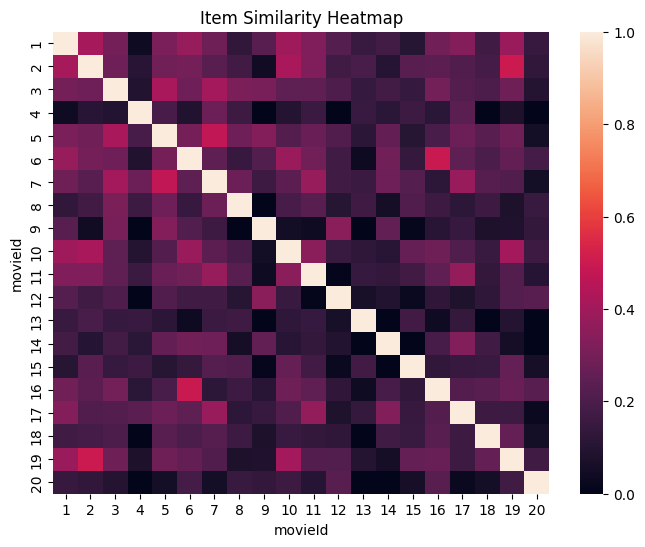

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20])
plt.title("Item Similarity Heatmap")
plt.show()

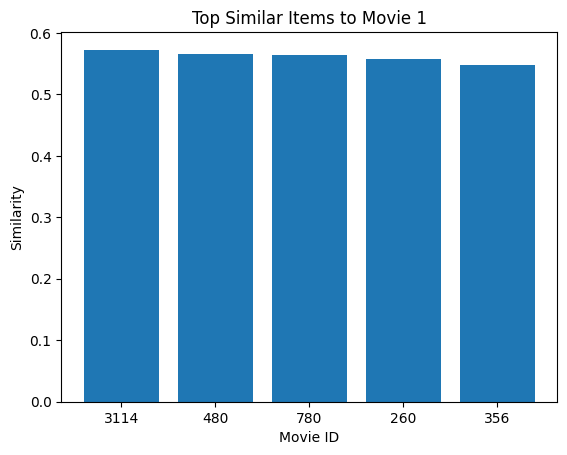

In [26]:
similar_items = get_similar_items(1, top_n=5)

plt.figure()
plt.bar(similar_items.index.astype(str), similar_items.values)
plt.title("Top Similar Items to Movie 1")
plt.xlabel("Movie ID")
plt.ylabel("Similarity")
plt.show()

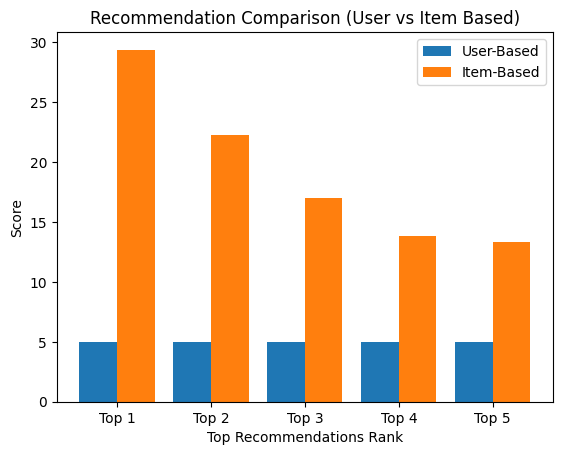

In [27]:

user_id = 1

user_recs = recommend_movies(user_id, top_n=5)
item_recs = recommend_items(user_id, top_n=5)

# Extract scores
user_scores = [x[1] for x in user_recs]
item_scores = [x[1] for x in item_recs]

# Labels
labels = [f"Top {i+1}" for i in range(5)]

# Plot
x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, user_scores, width=0.4, label='User-Based')
plt.bar(x + 0.2, item_scores, width=0.4, label='Item-Based')

plt.xticks(x, labels)
plt.xlabel("Top Recommendations Rank")
plt.ylabel("Score")
plt.title("Recommendation Comparison (User vs Item Based)")
plt.legend()

plt.show()

In [28]:
print("\n===== ACCURACY COMPARISON =====")
print("User-Based RMSE:", rmse_user)
print("Item-Based RMSE:", rmse_item)

if rmse_user < rmse_item:
    print("User-Based CF is more accurate")
else:
    print("Item-Based CF is more accurate")


===== ACCURACY COMPARISON =====
User-Based RMSE: 1.9228100565195427
Item-Based RMSE: 1.4803460260701553
Item-Based CF is more accurate
